# Sinhala Sign Language Alphabet — LSTM Sequence Classifier

This notebook trains a sequence-based LSTM model to classify Sinhala Sign Language alphabet videos using MediaPipe hand landmarks.

- **Input**: Preprocessed landmark sequences of shape `(SEQ_LEN, 126)` from `ssl_alphabet_sequences.pkl` (2 hands × 21 landmarks × 3 coordinates per frame).
- **Model**: Two-layer stacked LSTM with dropout and a dense softmax head.
- **Outputs**: Accuracy, full classification report, confusion matrix, and a saved Keras model + scaler for later webcam/inference use.

Use this notebook after running `preprocess_ssl_alphabet.ipynb`, which generates the sequence dataset.

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

print(f"TensorFlow : {tf.__version__}")
print(f"GPUs       : {tf.config.list_physical_devices('GPU')}")

TensorFlow : 2.16.1
GPUs       : []


In [3]:
DATA_PATH = Path("C:/Redmi/dataset/processed/ssl-alphabet-converted/ssl_alphabet_sequences.pkl")

with open(DATA_PATH, "rb") as f:
    data = pickle.load(f)

X_train = data["X_train"]
X_val   = data["X_val"]
X_test  = data["X_test"]
y_train = data["y_train"]
y_val   = data["y_val"]
y_test  = data["y_test"]
le          = data["label_encoder"]
num_classes = data["num_classes"]
SEQ_LEN     = data["seq_len"]
STRIDE      = data["stride"]

print(f"X_train : {X_train.shape}  (sequences, timesteps, features)")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")
print(f"Classes : {num_classes}")
print(f"SEQ_LEN : {SEQ_LEN}")
print(f"STRIDE  : {STRIDE}")
print(f"Labels  : {list(le.classes_)}")

X_train : (858, 30, 63)  (sequences, timesteps, features)
X_val   : (184, 30, 63)
X_test  : (184, 30, 63)
Classes : 46
SEQ_LEN : 30
STRIDE  : 5
Labels  : ['අ', 'අං', 'ආ', 'ඇ', 'ඈ', 'ඉ', 'ඊ', 'උ', 'ඌ', 'එ', 'ඒ', 'ඔ', 'ඕ', 'ක්', 'ඛි', 'ග්', 'ඟ', 'ච්', 'ඡ්', 'ජ්', 'ට්', 'ඨ්', 'ඩ්', 'ඪ්', 'ණ්', 'ඬ', 'ත්', 'ද්', 'ධ්', 'න්', 'ඳ', 'ප්', 'ඵ්', 'බ්', 'භ්', 'ම්', 'ය්', 'ර්', 'ල්', 'ව්', 'ශ්', 'ෂ්', 'ස්', 'හ්', 'ළ්', 'ෆ්']


In [4]:
n_train, n_steps, n_feats = X_train.shape

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train.reshape(-1, n_feats)).reshape(n_train, n_steps, n_feats)
X_val_s   = scaler.transform(X_val.reshape(-1, n_feats)).reshape(X_val.shape)
X_test_s  = scaler.transform(X_test.reshape(-1, n_feats)).reshape(X_test.shape)

print(f"Scaled X_train shape: {X_train_s.shape}")
print(f"Train mean ≈ {X_train_s.mean():.4f}, std ≈ {X_train_s.std():.4f}")

Scaled X_train shape: (858, 30, 63)
Train mean ≈ 0.0000, std ≈ 0.9759


In [7]:
model = keras.Sequential([
    layers.Input(shape=(SEQ_LEN, n_feats)),
    layers.LSTM(128, return_sequences=True),
    layers.Dropout(0.3),
    layers.LSTM(64),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(num_classes, activation="softmax"),
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 128)        │        98,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 46)             │         2,990 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 154,862 (604.93 KB)

 Trainable params: 154,862 (604.93 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
unique_classes = np.unique(y_train)
weights = compute_class_weight("balanced", classes=unique_classes, y=y_train)
class_weight = dict(zip(unique_classes.astype(int), weights))

EPOCHS     = 100
BATCH_SIZE = 32

cb_list = [
    callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=15,
        restore_best_weights=True,
        verbose=1,
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_accuracy",
        mode="max",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1,
    ),
]

history = model.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight,
    callbacks=cb_list,
)

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.1014 - loss: 3.6375 - val_accuracy: 0.2772 - val_loss: 3.3339 - learning_rate: 0.0010
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2751 - loss: 3.0699 - val_accuracy: 0.4130 - val_loss: 2.6584 - learning_rate: 0.0010
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4312 - loss: 2.3908 - val_accuracy: 0.6359 - val_loss: 1.8711 - learning_rate: 0.0010
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5559 - loss: 1.7591 - val_accuracy: 0.6902 - val_loss: 1.3017 - learning_rate: 0.0010
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6527 - loss: 1.3371 - val_accuracy: 0.6793 - val_loss: 1.1018 - learning_rate: 0.0010
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6678 - loss: 1.1181 - val_accuracy: 0.7880 - val_loss: 0.7821 - learning_rate: 0.0010
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7203 - loss: 0.8756 - 

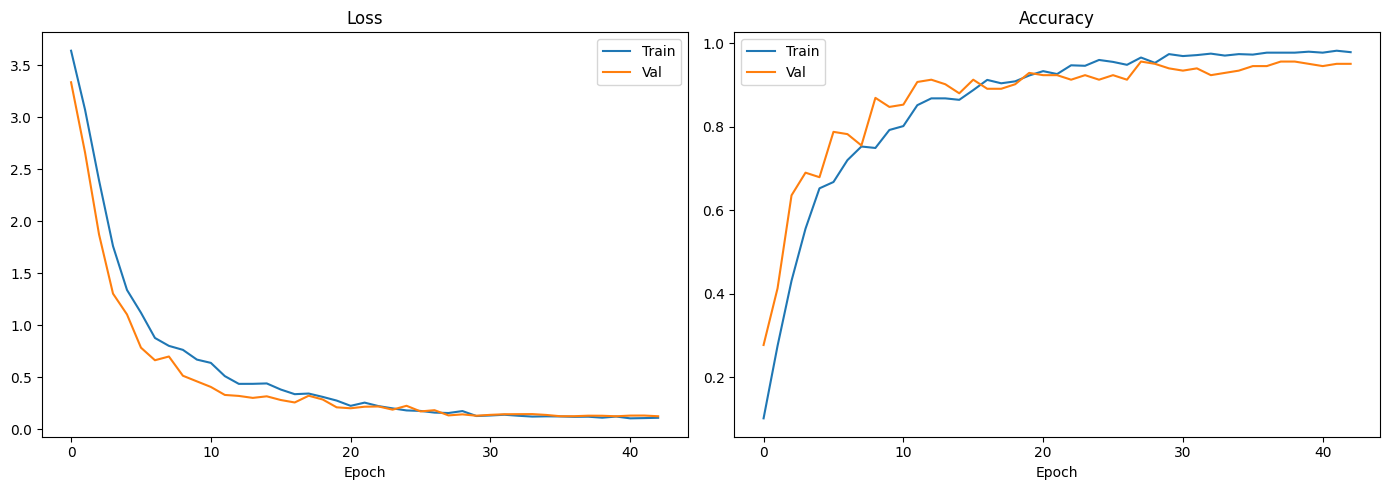

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history["loss"], label="Train")
ax1.plot(history.history["val_loss"], label="Val")
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(history.history["accuracy"], label="Train")
ax2.plot(history.history["val_accuracy"], label="Val")
ax2.set_title("Accuracy")
ax2.set_xlabel("Epoch")
ax2.legend()

plt.tight_layout()
plt.show()

Test accuracy : 0.9239
Test loss     : 0.1912

--- Classification Report ---
              precision    recall  f1-score   support

           අ       1.00      1.00      1.00         4
          අං       1.00      1.00      1.00         1
           ආ       1.00      1.00      1.00         7
           ඇ       0.75      1.00      0.86         3
           ඈ       1.00      0.50      0.67         2
           ඉ       1.00      1.00      1.00         5
           ඊ       1.00      1.00      1.00         3
           ඌ       1.00      0.75      0.86         4
           එ       1.00      1.00      1.00         2
           ඔ       0.86      1.00      0.92         6
           ඕ       1.00      0.86      0.92         7
          ක්       0.75      1.00      0.86         3
          ඛි       1.00      1.00      1.00         3
          ග්       1.00      1.00      1.00         5
           ඟ       1.00      1.00      1.00         4
          ච්       0.50      1.00      0.67         1
    

c:\Users\sayur\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3461 (\N{SINHALA LETTER AYANNA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\sayur\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\utils.py:61: UserWarning: Matplotlib currently does not support Sinhala natively.
  fig.canvas.draw()
c:\Users\sayur\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3458 (\N{SINHALA SIGN ANUSVARAYA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\sayur\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3462 (\N{SINHALA LETTER AAYANNA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\sayur\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3463 (\N{SINHALA LETTER AEYANNA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\sayu

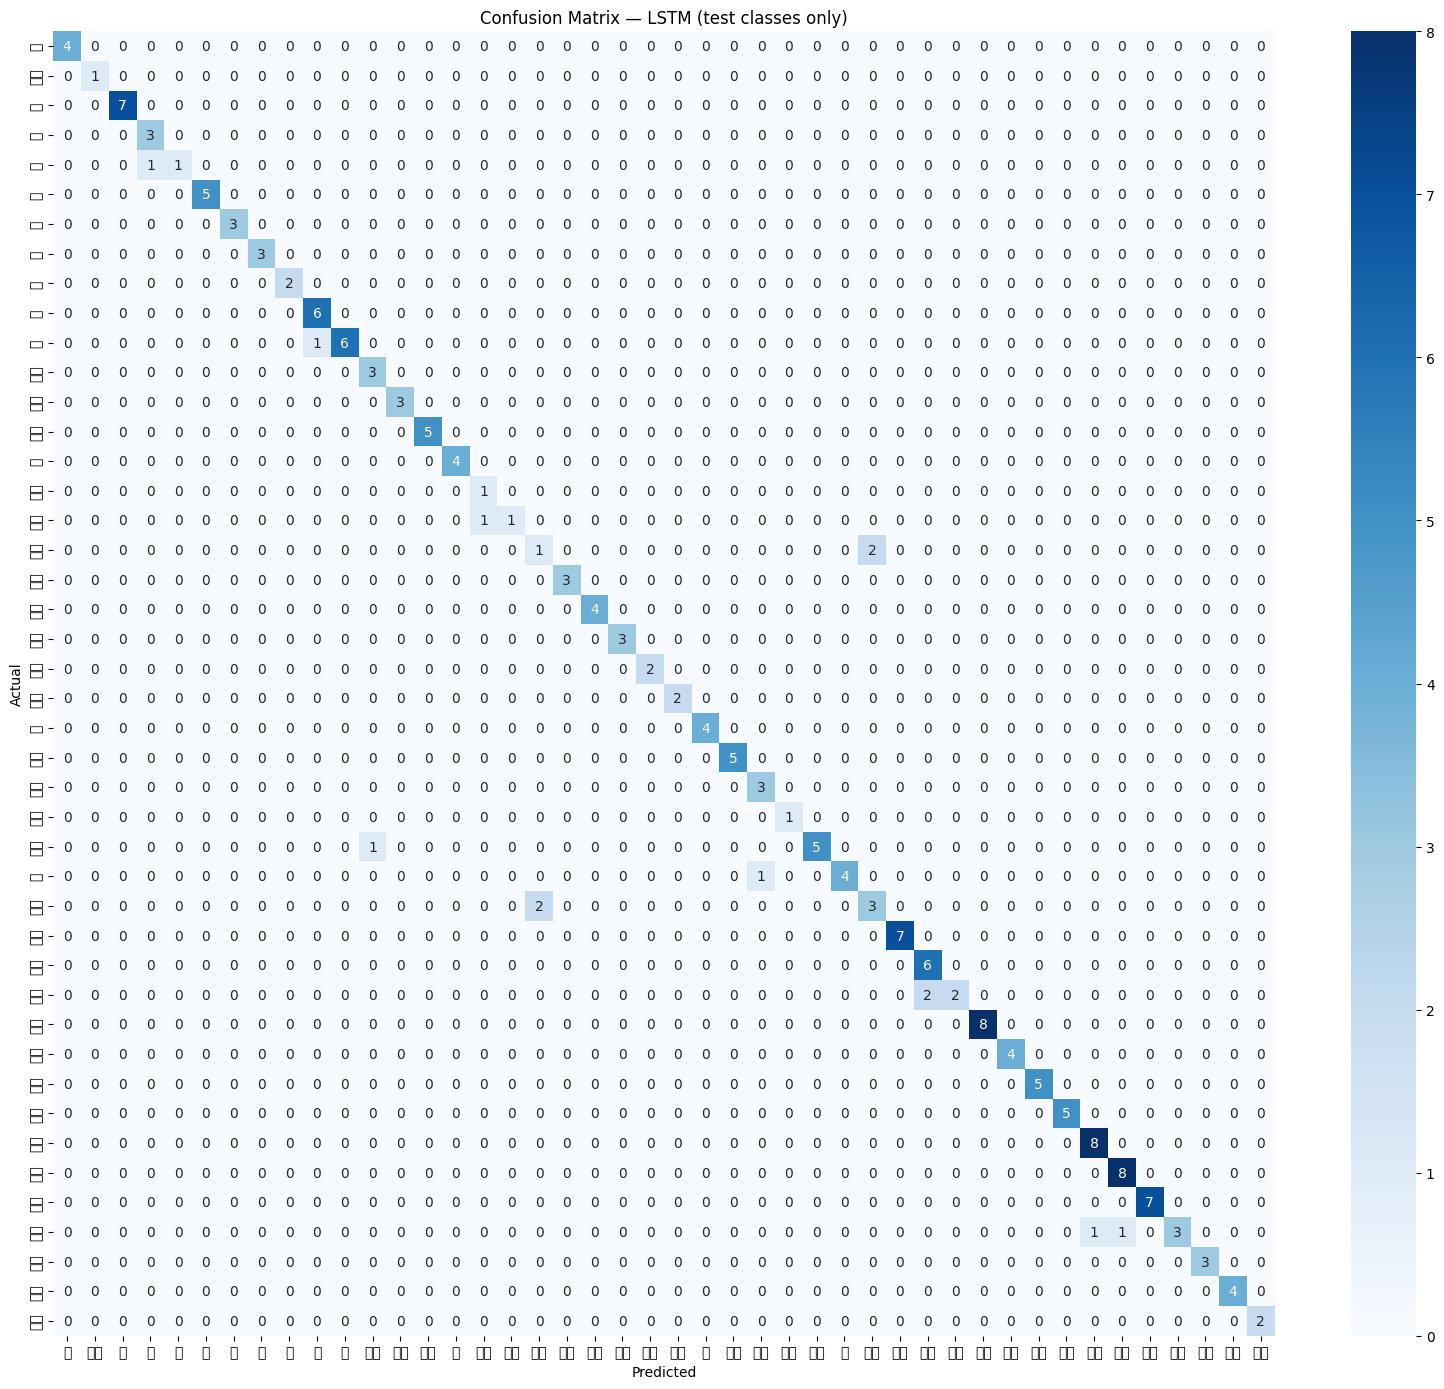

In [10]:
test_loss, test_acc = model.evaluate(X_test_s, y_test, verbose=0)
print(f"Test accuracy : {test_acc:.4f}")
print(f"Test loss     : {test_loss:.4f}")

y_pred = model.predict(X_test_s, verbose=0).argmax(axis=1)

# Classes actually present in the test set
labels_present = np.unique(y_test)
label_names_present = [le.classes_[i] for i in labels_present]

print("\n--- Classification Report ---")
print(
    classification_report(
        y_test,
        y_pred,
        labels=labels_present,
        target_names=label_names_present,
        zero_division=0,
    )
)

cm = confusion_matrix(y_test, y_pred, labels=labels_present)
fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names_present,
    yticklabels=label_names_present,
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — LSTM (test classes only)")
plt.tight_layout()
plt.show()

In [12]:
MODEL_DIR = Path("C:/Redmi/models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

model.save(MODEL_DIR / "ssl_alphabet_lstm.keras")
print(f"Model saved to {MODEL_DIR / 'ssl_alphabet_lstm.keras'}")

with open(MODEL_DIR / "ssl_alphabet_lstm_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
print(f"Scaler saved to {MODEL_DIR / 'ssl_alphabet_lstm_scaler.pkl'}")

Model saved to C:\Redmi\models\ssl_alphabet_lstm.keras
Scaler saved to C:\Redmi\models\ssl_alphabet_lstm_scaler.pkl


In [14]:
np.random.seed(76)
n_demo = 10
demo_idx = np.random.choice(len(X_test_s), size=n_demo, replace=False)

demo_X = X_test_s[demo_idx]
demo_y = y_test[demo_idx]

preds = model.predict(demo_X, verbose=0).argmax(axis=1)

print(f"{'#':>3}  {'Actual':>8}  {'Predicted':>10}  {'Match':>5}")
print("-" * 35)
for i, (true_label, pred_label) in enumerate(zip(demo_y, preds)):
    actual    = le.inverse_transform([true_label])[0]
    predicted = le.inverse_transform([pred_label])[0]
    match     = "✓" if true_label == pred_label else "✗"
    print(f"{i+1:>3}  {actual:>8}  {predicted:>10}  {match:>5}")

  #    Actual   Predicted  Match
-----------------------------------
  1        බ්          බ්      ✓
  2        න්          න්      ✓
  3         ඊ           ඊ      ✓
  4        ම්          ම්      ✓
  5        අං          අං      ✓
  6        ඪ්          ඪ්      ✓
  7         එ           එ      ✓
  8        ම්          ම්      ✓
  9        ඵ්          ඵ්      ✓
 10        ළ්          ළ්      ✓
